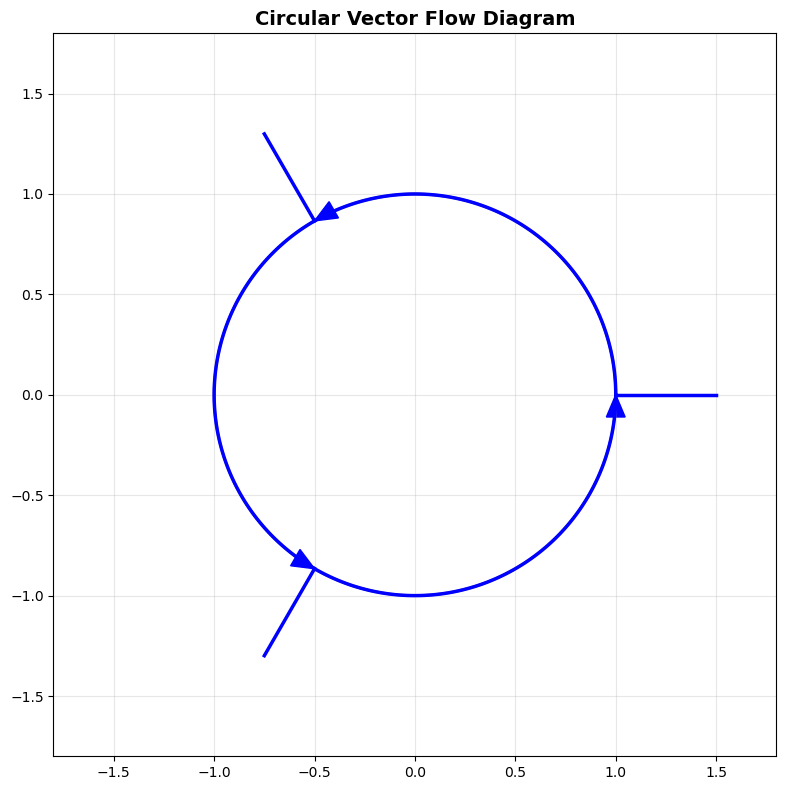

Diagram saved as 'circular_vector_flow.png'


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, FancyArrowPatch, Polygon

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Circle parameters
center = (0, 0)
radius = 1.0

# Draw the central circle
circle = Circle(center, radius, fill=False, edgecolor='gray', linewidth=2)
ax.add_patch(circle)

# Number of arrows
n_arrows = 3
angle_step = 360 / n_arrows  # 120 degrees
arc_angle = 120  # How many degrees each arrow follows the circle

# Parameters for arrows
approach_distance = 0.5  # How far outside the circle the arrow starts

for i in range(n_arrows):
    # Starting angle for this arrow (in degrees)
    start_angle = i * angle_step
    start_rad = np.radians(start_angle)
    
    # End angle after following the circle
    end_angle = start_angle + arc_angle
    end_rad = np.radians(end_angle)
    
    # Point where arrow approaches from (outside the circle)
    approach_point = (
        center[0] + (radius + approach_distance) * np.cos(start_rad),
        center[1] + (radius + approach_distance) * np.sin(start_rad)
    )
    
    # Point where arrow touches the circle
    touch_point = (
        center[0] + radius * np.cos(start_rad),
        center[1] + radius * np.sin(start_rad)
    )
    
    # Point where arrow ends (after following circle)
    end_point = (
        center[0] + radius * np.cos(end_rad),
        center[1] + radius * np.sin(end_rad)
    )
    
    # Draw straight approach line
    ax.plot([approach_point[0], touch_point[0]], 
            [approach_point[1], touch_point[1]], 
            'b-', linewidth=2.5)
    
    # Create curved path along the circle
    # Generate points along the arc
    angles = np.linspace(start_angle, end_angle, 100)
    arc_x = center[0] + radius * np.cos(np.radians(angles))
    arc_y = center[1] + radius * np.sin(np.radians(angles))
    
    # Draw the arc
    ax.plot(arc_x, arc_y, 'b-', linewidth=2.5)
    
    # Add arrowhead at the end
    # Calculate tangent direction (perpendicular to radius, clockwise)
    arrow_angle = end_rad + np.pi/2  # Tangent to circle (90 degrees ahead)
    arrow_size = 0.12
    
    # Arrowhead triangle
    arrow_tip = end_point
    arrow_base1 = (
        end_point[0] - arrow_size * np.cos(arrow_angle - 0.4),
        end_point[1] - arrow_size * np.sin(arrow_angle - 0.4)
    )
    arrow_base2 = (
        end_point[0] - arrow_size * np.cos(arrow_angle + 0.4),
        end_point[1] - arrow_size * np.sin(arrow_angle + 0.4)
    )
    
    arrow = Polygon([arrow_tip, arrow_base1, arrow_base2], 
                   closed=True, facecolor='blue', edgecolor='blue')
    ax.add_patch(arrow)

# Set equal aspect ratio and limits
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.grid(True, alpha=0.3)
ax.set_title('Circular Vector Flow Diagram', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('circular_vector_flow.png', dpi=300, bbox_inches='tight')
plt.show()

print("Diagram saved as 'circular_vector_flow.png'")

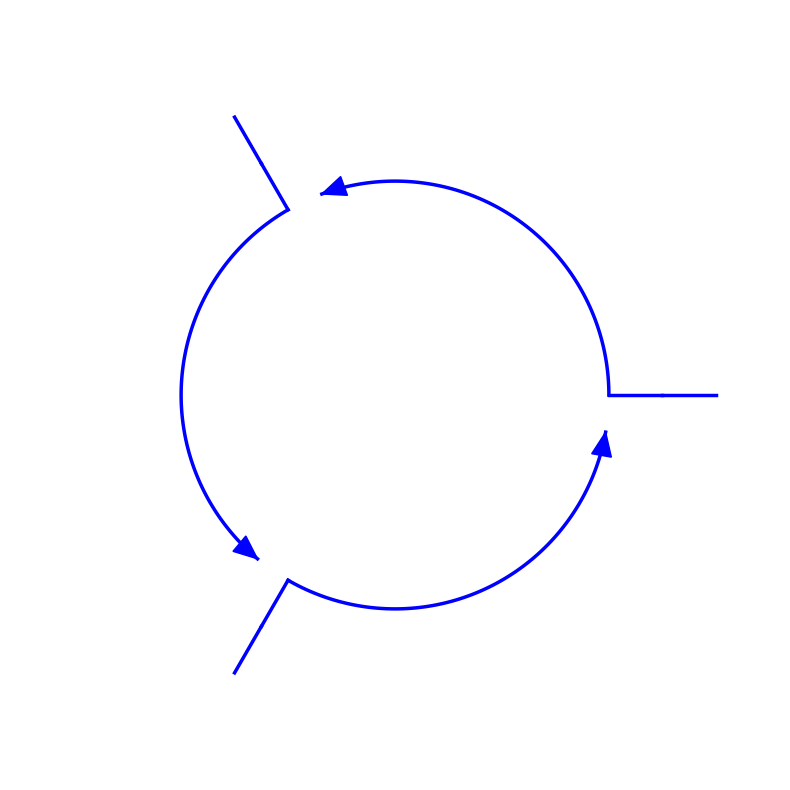

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, FancyArrowPatch, Polygon

# Create figure with transparent background
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='none')
ax.set_facecolor('none')

# Number of arrows
n_arrows = 3
angle_step = 360 / n_arrows  # 120 degrees
arc_angle = 110  # How many degrees each arrow follows the circle (leaving gap)

# Parameters for arrows
approach_distance = 0.5  # How far outside the circle the arrow starts

for i in range(n_arrows):
    # Starting angle for this arrow (in degrees)
    start_angle = i * angle_step
    start_rad = np.radians(start_angle)
    
    # End angle after following the circle
    end_angle = start_angle + arc_angle
    end_rad = np.radians(end_angle)
    
    # Point where arrow approaches from (outside the circle)
    approach_point = (
        center[0] + (radius + approach_distance) * np.cos(start_rad),
        center[1] + (radius + approach_distance) * np.sin(start_rad)
    )
    
    # Point where arrow touches the circle
    touch_point = (
        center[0] + radius * np.cos(start_rad),
        center[1] + radius * np.sin(start_rad)
    )
    
    # Point where arrow ends (after following circle)
    end_point = (
        center[0] + radius * np.cos(end_rad),
        center[1] + radius * np.sin(end_rad)
    )
    
    # Draw straight approach line (shorter to make room for curve)
    curve_start_distance = 0.25  # Start curving before reaching circle
    curve_start = (
        center[0] + (radius + curve_start_distance) * np.cos(start_rad),
        center[1] + (radius + curve_start_distance) * np.sin(start_rad)
    )
    
    ax.plot([approach_point[0], curve_start[0]], 
            [approach_point[1], curve_start[1]], 
            'b-', linewidth=2.5)
    
    # Create smooth curve from approach to circle using quadratic bezier
    # Control point for smooth curve
    control_distance = 0.15
    control_point = (
        center[0] + (radius + control_distance) * np.cos(start_rad),
        center[1] + (radius + control_distance) * np.sin(start_rad)
    )
    
    # Bezier curve from curve_start to touch_point
    t = np.linspace(0, 1, 30)
    bezier_x = (1-t)**2 * curve_start[0] + 2*(1-t)*t * control_point[0] + t**2 * touch_point[0]
    bezier_y = (1-t)**2 * curve_start[1] + 2*(1-t)*t * control_point[1] + t**2 * touch_point[1]
    ax.plot(bezier_x, bezier_y, 'b-', linewidth=2.5)
    
    # Create curved path along the circle
    # Generate points along the arc
    angles = np.linspace(start_angle, end_angle, 100)
    arc_x = center[0] + radius * np.cos(np.radians(angles))
    arc_y = center[1] + radius * np.sin(np.radians(angles))
    
    # Draw the arc
    ax.plot(arc_x, arc_y, 'b-', linewidth=2.5)
    
    # Add arrowhead at the end
    # Calculate tangent direction (perpendicular to radius, clockwise)
    arrow_angle = end_rad + np.pi/2  # Tangent to circle (90 degrees ahead)
    arrow_size = 0.12
    
    # Arrowhead triangle
    arrow_tip = end_point
    arrow_base1 = (
        end_point[0] - arrow_size * np.cos(arrow_angle - 0.4),
        end_point[1] - arrow_size * np.sin(arrow_angle - 0.4)
    )
    arrow_base2 = (
        end_point[0] - arrow_size * np.cos(arrow_angle + 0.4),
        end_point[1] - arrow_size * np.sin(arrow_angle + 0.4)
    )
    
    arrow = Polygon([arrow_tip, arrow_base1, arrow_base2], 
                   closed=True, facecolor='blue', edgecolor='blue')
    ax.add_patch(arrow)

# Set equal aspect ratio and limits - no grid or axes
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.axis('off')  # Remove axes and grid

plt.tight_layout()
plt.savefig('circular_vector_flow.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()



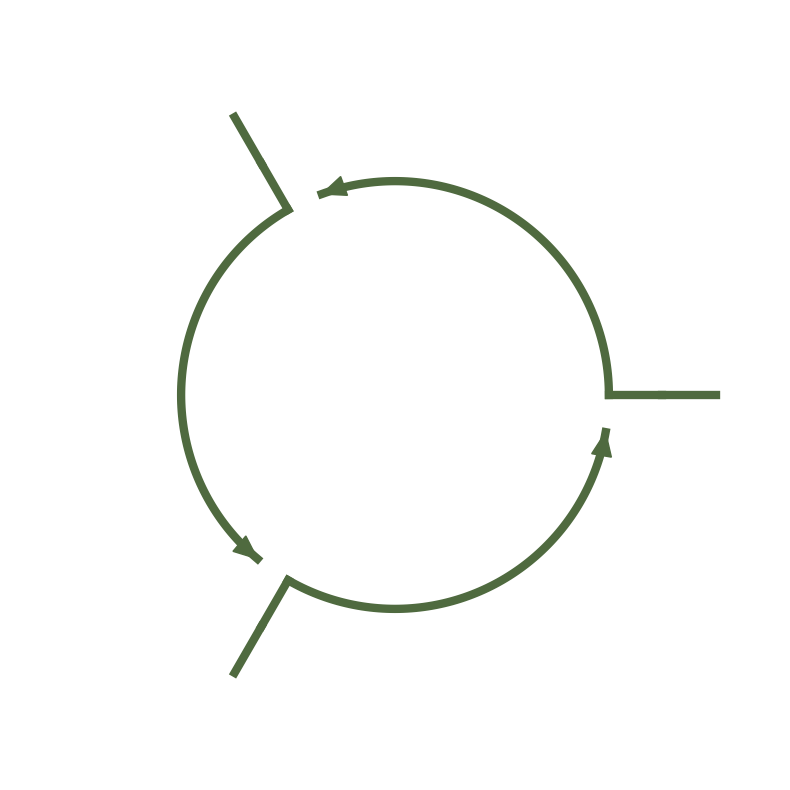

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# ==============================
# CONFIGURATION VARIABLES
# ==============================

# Figure
FIG_SIZE = (8, 8)
BACKGROUND_COLOR = 'none'

# Circle + Arrow geometry
CENTER = (0, 0)
RADIUS = 1.0
N_ARROWS = 3
ARC_ANGLE = 110         # Degrees each arrow follows along circle
APPROACH_DISTANCE = 0.5 # How far outside circle arrow starts
CURVE_START_DIST = 0.25 # Where curve to circle begins
CONTROL_DIST = 0.15     # Bezier control point distance

# Arrowhead
ARROW_SIZE = 0.12
ARROW_SPREAD = 0.4      # Wider or narrower triangle

# Style
ARROW_COLOR = '#4F6A3F'
LINE_WIDTH = 6

# Output
SAVE_PATH = 'circular_vector_flow.png'
DPI = 300

# ==============================
# DRAWING LOGIC
# ==============================

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor=BACKGROUND_COLOR)
ax.set_facecolor(BACKGROUND_COLOR)

angle_step = 360 / N_ARROWS

for i in range(N_ARROWS):
    start_angle = i * angle_step
    end_angle = start_angle + ARC_ANGLE
    start_rad = np.radians(start_angle)
    end_rad = np.radians(end_angle)
    
    # Key geometry points
    approach_point = (
        CENTER[0] + (RADIUS + APPROACH_DISTANCE) * np.cos(start_rad),
        CENTER[1] + (RADIUS + APPROACH_DISTANCE) * np.sin(start_rad)
    )
    curve_start = (
        CENTER[0] + (RADIUS + CURVE_START_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CURVE_START_DIST) * np.sin(start_rad)
    )
    control_point = (
        CENTER[0] + (RADIUS + CONTROL_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CONTROL_DIST) * np.sin(start_rad)
    )
    touch_point = (
        CENTER[0] + RADIUS * np.cos(start_rad),
        CENTER[1] + RADIUS * np.sin(start_rad)
    )
    end_point = (
        CENTER[0] + RADIUS * np.cos(end_rad),
        CENTER[1] + RADIUS * np.sin(end_rad)
    )
    
    # --- 1. Approach line
    ax.plot(
        [approach_point[0], curve_start[0]],
        [approach_point[1], curve_start[1]],
        color=ARROW_COLOR,
        linewidth=LINE_WIDTH
    )
    
    # --- 2. Bezier curve from approach to circle
    t = np.linspace(0, 1, 30)
    bezier_x = (1-t)**2 * curve_start[0] + 2*(1-t)*t * control_point[0] + t**2 * touch_point[0]
    bezier_y = (1-t)**2 * curve_start[1] + 2*(1-t)*t * control_point[1] + t**2 * touch_point[1]
    ax.plot(bezier_x, bezier_y, color=ARROW_COLOR, linewidth=LINE_WIDTH)
    
    # --- 3. Arc along circle
    angles = np.linspace(start_angle, end_angle, 100)
    arc_x = CENTER[0] + RADIUS * np.cos(np.radians(angles))
    arc_y = CENTER[1] + RADIUS * np.sin(np.radians(angles))
    ax.plot(arc_x, arc_y, color=ARROW_COLOR, linewidth=LINE_WIDTH)
    
    # --- 4. Arrowhead
    arrow_angle = end_rad + np.pi/2  # Tangent direction
    arrow_tip = end_point
    arrow_base1 = (
        end_point[0] - ARROW_SIZE * np.cos(arrow_angle - ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(arrow_angle - ARROW_SPREAD)
    )
    arrow_base2 = (
        end_point[0] - ARROW_SIZE * np.cos(arrow_angle + ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(arrow_angle + ARROW_SPREAD)
    )
    
    arrow = Polygon(
        [arrow_tip, arrow_base1, arrow_base2],
        closed=True,
        facecolor=ARROW_COLOR,
        edgecolor=ARROW_COLOR
    )
    ax.add_patch(arrow)

# ==============================
# FINALIZE PLOT
# ==============================
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.axis('off')

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI, bbox_inches='tight', transparent=True)
plt.show()

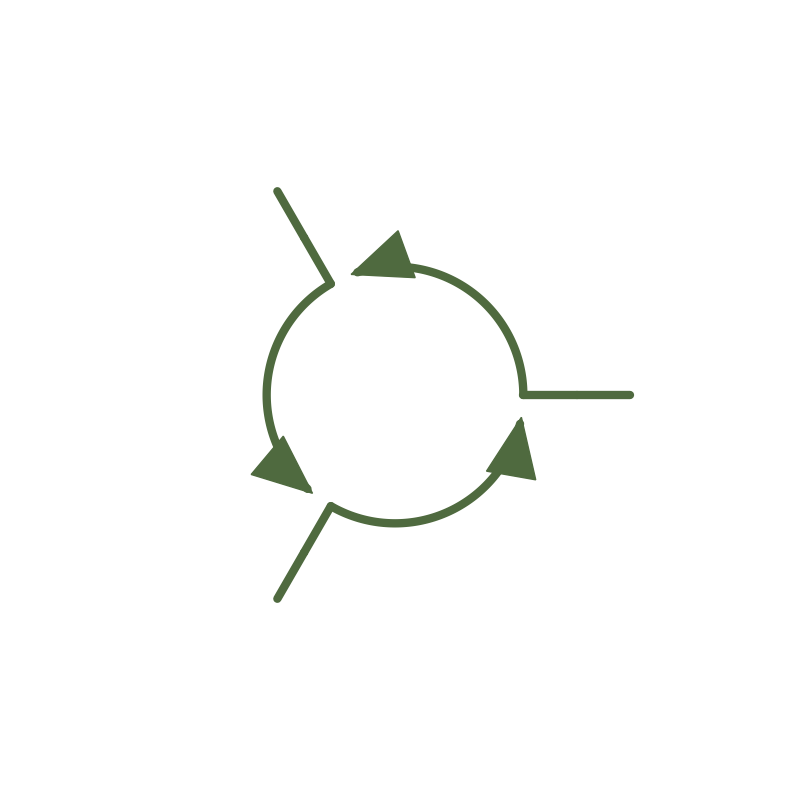

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# ==============================
# CONFIGURATION VARIABLES
# ==============================

# Figure
FIG_SIZE = (8, 8)
BACKGROUND_COLOR = 'none'

# Circle + Arrow geometry
CENTER = (0, 0)
RADIUS = 0.6
N_ARROWS = 3
ARC_ANGLE = 110         # Degrees each arrow follows along circle
APPROACH_DISTANCE = 0.5 # How far outside circle arrow starts
CURVE_START_DIST = 0.25 # Where curve to circle begins
CONTROL_DIST = 0.15     # Bezier control point distance

# Arrowhead
ARROW_SIZE = 0.3    # Length of arrowhead triangle
ARROW_SPREAD = 0.4      # Wider or narrower triangle
ARROW_END_OFFSET = 3    # How many degrees of arc to shorten so line doesn’t show through

# Style
ARROW_COLOR = '#4F6A3F' # blue
LINE_WIDTH = 6

# Output
SAVE_PATH = 'circular_vector_flow.png'
DPI = 300

# ==============================
# DRAWING LOGIC
# ==============================

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor=BACKGROUND_COLOR)
ax.set_facecolor(BACKGROUND_COLOR)

angle_step = 360 / N_ARROWS

for i in range(N_ARROWS):
    start_angle = i * angle_step
    end_angle = start_angle + ARC_ANGLE
    start_rad = np.radians(start_angle)
    end_rad = np.radians(end_angle)

    # Key geometry points
    approach_point = (
        CENTER[0] + (RADIUS + APPROACH_DISTANCE) * np.cos(start_rad),
        CENTER[1] + (RADIUS + APPROACH_DISTANCE) * np.sin(start_rad)
    )
    curve_start = (
        CENTER[0] + (RADIUS + CURVE_START_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CURVE_START_DIST) * np.sin(start_rad)
    )
    control_point = (
        CENTER[0] + (RADIUS + CONTROL_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CONTROL_DIST) * np.sin(start_rad)
    )
    touch_point = (
        CENTER[0] + RADIUS * np.cos(start_rad),
        CENTER[1] + RADIUS * np.sin(start_rad)
    )
    end_point = (
        CENTER[0] + RADIUS * np.cos(end_rad),
        CENTER[1] + RADIUS * np.sin(end_rad)
    )

    # --- 1. Approach line
    ax.plot(
        [approach_point[0], curve_start[0]],
        [approach_point[1], curve_start[1]],
        color=ARROW_COLOR,
        linewidth=LINE_WIDTH,
        solid_capstyle='round'
    )

    # --- 2. Bezier curve from approach to circle
    t = np.linspace(0, 1, 30)
    bezier_x = (1-t)**2 * curve_start[0] + 2*(1-t)*t * control_point[0] + t**2 * touch_point[0]
    bezier_y = (1-t)**2 * curve_start[1] + 2*(1-t)*t * control_point[1] + t**2 * touch_point[1]
    ax.plot(bezier_x, bezier_y, color=ARROW_COLOR, linewidth=LINE_WIDTH, solid_capstyle='round')

    # --- 3. Arc along circle (shortened slightly before arrow tip)
    angles = np.linspace(start_angle, end_angle - ARROW_END_OFFSET, 100)
    arc_x = CENTER[0] + RADIUS * np.cos(np.radians(angles))
    arc_y = CENTER[1] + RADIUS * np.sin(np.radians(angles))
    ax.plot(arc_x, arc_y, color=ARROW_COLOR, linewidth=LINE_WIDTH, solid_capstyle='round')

    # --- 4. Arrowhead
    arrow_angle = end_rad + np.pi/2  # Tangent direction
    arrow_tip = end_point
    arrow_base1 = (
        end_point[0] - ARROW_SIZE * np.cos(arrow_angle - ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(arrow_angle - ARROW_SPREAD)
    )
    arrow_base2 = (
        end_point[0] - ARROW_SIZE * np.cos(arrow_angle + ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(arrow_angle + ARROW_SPREAD)
    )

    arrow = Polygon(
        [arrow_tip, arrow_base1, arrow_base2],
        closed=True,
        facecolor=ARROW_COLOR,
        edgecolor=ARROW_COLOR
    )
    ax.add_patch(arrow)

# ==============================
# FINALIZE PLOT
# ==============================
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.axis('off')

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI, bbox_inches='tight', transparent=True)
plt.show()

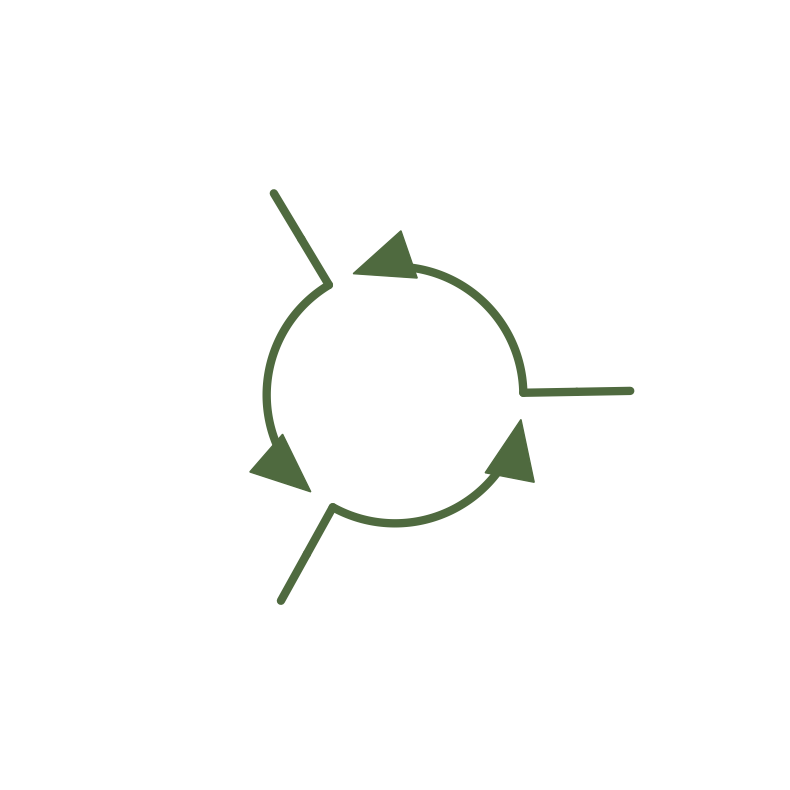

In [72]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# ==============================
# CONFIGURATION VARIABLES
# ==============================

# Figure
FIG_SIZE = (8, 8)
BACKGROUND_COLOR = 'none'

# Circle + Arrow geometry
CENTER = (0, 0)
RADIUS = 0.6
N_ARROWS = 3
ARC_ANGLE = 110         # Degrees each arrow follows along circle
APPROACH_DISTANCE = 0.5 # How far outside circle arrow starts
CURVE_START_DIST = 0.25 # Where curve to circle begins
CONTROL_DIST = 0.15     # Bezier control point distance

# Arrowhead
ARROW_SIZE = 0.3        # Length of arrowhead triangle
ARROW_SPREAD = 0.4      # Wider or narrower triangle
ARROW_END_OFFSET = 15    # Shorten so line doesn’t show through

# === NEW CONTROLS ===
ARROW_ROTATION_OFFSET = 1   # Rotate all arrows around circle (degrees)
ARROW_HEAD_SHIFT = -2        # Move arrowhead along circle path (+/- degrees)

# Style
ARROW_COLOR = '#4F6A3F'
LINE_WIDTH = 6

# Output
SAVE_PATH = 'circular_vector_flow.png'
DPI = 300

# ==============================
# DRAWING LOGIC
# ==============================

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor=BACKGROUND_COLOR)
ax.set_facecolor(BACKGROUND_COLOR)

angle_step = 360 / N_ARROWS

for i in range(N_ARROWS):
    start_angle = i * angle_step + ARROW_ROTATION_OFFSET
    end_angle = start_angle + ARC_ANGLE
    start_rad = np.radians(start_angle)
    end_rad = np.radians(end_angle)

    # Key geometry points
    approach_point = (
        CENTER[0] + (RADIUS + APPROACH_DISTANCE) * np.cos(start_rad),
        CENTER[1] + (RADIUS + APPROACH_DISTANCE) * np.sin(start_rad)
    )
    curve_start = (
        CENTER[0] + (RADIUS + CURVE_START_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CURVE_START_DIST) * np.sin(start_rad)
    )
    control_point = (
        CENTER[0] + (RADIUS + CONTROL_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CONTROL_DIST) * np.sin(start_rad)
    )
    touch_point = (
        CENTER[0] + RADIUS * np.cos(start_rad),
        CENTER[1] + RADIUS * np.sin(start_rad)
    )
    end_point = (
        CENTER[0] + RADIUS * np.cos(np.radians(end_angle + ARROW_HEAD_SHIFT)),
        CENTER[1] + RADIUS * np.sin(np.radians(end_angle + ARROW_HEAD_SHIFT))
    )

    # --- 1. Approach line
    ax.plot(
        [approach_point[0], curve_start[0]],
        [approach_point[1], curve_start[1]],
        color=ARROW_COLOR,
        linewidth=LINE_WIDTH,
        solid_capstyle='round'
    )

    # --- 2. Bezier curve (approach → circle)
    t = np.linspace(0, 1, 30)
    bezier_x = (1-t)**2 * curve_start[0] + 2*(1-t)*t * control_point[0] + t**2 * touch_point[0]
    bezier_y = (1-t)**2 * curve_start[1] + 2*(1-t)*t * control_point[1] + t**2 * touch_point[1]
    ax.plot(bezier_x, bezier_y, color=ARROW_COLOR, linewidth=LINE_WIDTH, solid_capstyle='round')

    # --- 3. Arc along circle
    angles = np.linspace(start_angle, end_angle - ARROW_END_OFFSET, 100)
    arc_x = CENTER[0] + RADIUS * np.cos(np.radians(angles))
    arc_y = CENTER[1] + RADIUS * np.sin(np.radians(angles))
    ax.plot(arc_x, arc_y, color=ARROW_COLOR, linewidth=LINE_WIDTH, solid_capstyle='round')

    # --- 4. Arrowhead
    arrow_angle = np.radians(end_angle + ARROW_HEAD_SHIFT + 90)  # tangent direction
    arrow_tip = end_point
    arrow_base1 = (
        end_point[0] - ARROW_SIZE * np.cos(arrow_angle - ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(arrow_angle - ARROW_SPREAD)
    )
    arrow_base2 = (
        end_point[0] - ARROW_SIZE * np.cos(arrow_angle + ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(arrow_angle + ARROW_SPREAD)
    )

    arrow = Polygon(
        [arrow_tip, arrow_base1, arrow_base2],
        closed=True,
        facecolor=ARROW_COLOR,
        edgecolor=ARROW_COLOR
    )
    ax.add_patch(arrow)

# ==============================
# FINALIZE PLOT
# ==============================
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.axis('off')

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI, bbox_inches='tight', transparent=True)
plt.show()

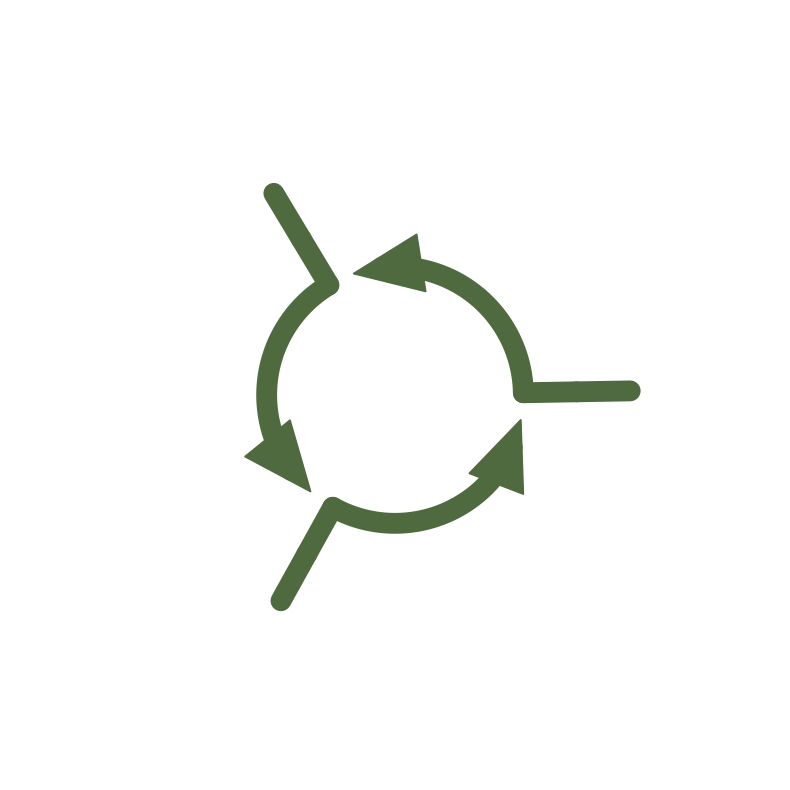

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# ==============================
# CONFIGURATION VARIABLES
# ==============================

# Figure
FIG_SIZE = (8, 8)
BACKGROUND_COLOR = 'none'

# Circle + Arrow geometry
CENTER = (0, 0)
RADIUS = 0.6
N_ARROWS = 3
ARC_ANGLE = 110         # Degrees each arrow follows along circle
APPROACH_DISTANCE = 0.5 # How far outside circle arrow starts
CURVE_START_DIST = 0.25 # Where curve to circle begins
CONTROL_DIST = 0.15     # Bezier control point distance

# Arrowhead
ARROW_SIZE = 0.35        # Length of arrowhead triangle
ARROW_SPREAD = 0.4      # Wider or narrower triangle
ARROW_END_OFFSET = 15   # Shorten so line doesn’t show through

# === NEW CONTROLS ===
ARROW_ROTATION_OFFSET = 1   # Rotate all arrows around circle (degrees)
ARROW_HEAD_SHIFT = -2       # Move arrowhead along circle path (+/- degrees)
ARROW_HEAD_ROTATE = -10       # Rotate all arrowheads around their own center (degrees)

# Style
ARROW_COLOR = '#4F6A3F'
LINE_WIDTH = 15

# Output
SAVE_PATH = 'circular_vector_flow.png'
DPI = 300

# ==============================
# DRAWING LOGIC
# ==============================

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor=BACKGROUND_COLOR)
ax.set_facecolor(BACKGROUND_COLOR)

angle_step = 360 / N_ARROWS

for i in range(N_ARROWS):
    start_angle = i * angle_step + ARROW_ROTATION_OFFSET
    end_angle = start_angle + ARC_ANGLE
    start_rad = np.radians(start_angle)
    end_rad = np.radians(end_angle)

    # Key geometry points
    approach_point = (
        CENTER[0] + (RADIUS + APPROACH_DISTANCE) * np.cos(start_rad),
        CENTER[1] + (RADIUS + APPROACH_DISTANCE) * np.sin(start_rad)
    )
    curve_start = (
        CENTER[0] + (RADIUS + CURVE_START_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CURVE_START_DIST) * np.sin(start_rad)
    )
    control_point = (
        CENTER[0] + (RADIUS + CONTROL_DIST) * np.cos(start_rad),
        CENTER[1] + (RADIUS + CONTROL_DIST) * np.sin(start_rad)
    )
    touch_point = (
        CENTER[0] + RADIUS * np.cos(start_rad),
        CENTER[1] + RADIUS * np.sin(start_rad)
    )
    end_point = (
        CENTER[0] + RADIUS * np.cos(np.radians(end_angle + ARROW_HEAD_SHIFT)),
        CENTER[1] + RADIUS * np.sin(np.radians(end_angle + ARROW_HEAD_SHIFT))
    )

    # --- 1. Approach line
    ax.plot(
        [approach_point[0], curve_start[0]],
        [approach_point[1], curve_start[1]],
        color=ARROW_COLOR,
        linewidth=LINE_WIDTH,
        solid_capstyle='round'
    )

    # --- 2. Bezier curve (approach → circle)
    t = np.linspace(0, 1, 30)
    bezier_x = (1-t)**2 * curve_start[0] + 2*(1-t)*t * control_point[0] + t**2 * touch_point[0]
    bezier_y = (1-t)**2 * curve_start[1] + 2*(1-t)*t * control_point[1] + t**2 * touch_point[1]
    ax.plot(bezier_x, bezier_y, color=ARROW_COLOR, linewidth=LINE_WIDTH, solid_capstyle='round')

    # --- 3. Arc along circle
    angles = np.linspace(start_angle, end_angle - ARROW_END_OFFSET, 100)
    arc_x = CENTER[0] + RADIUS * np.cos(np.radians(angles))
    arc_y = CENTER[1] + RADIUS * np.sin(np.radians(angles))
    ax.plot(arc_x, arc_y, color=ARROW_COLOR, linewidth=LINE_WIDTH, solid_capstyle='round')

    # --- 4. Arrowhead
    base_angle = np.radians(end_angle + ARROW_HEAD_SHIFT + 90)
    arrow_tip = end_point
    arrow_base1 = (
        end_point[0] - ARROW_SIZE * np.cos(base_angle - ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(base_angle - ARROW_SPREAD)
    )
    arrow_base2 = (
        end_point[0] - ARROW_SIZE * np.cos(base_angle + ARROW_SPREAD),
        end_point[1] - ARROW_SIZE * np.sin(base_angle + ARROW_SPREAD)
    )

    # Apply rotation of the entire arrowhead around its tip
    rotation_rad = np.radians(ARROW_HEAD_ROTATE)
    def rotate_point(px, py, cx, cy, theta):
        """Rotate point (px, py) around center (cx, cy) by theta radians."""
        dx, dy = px - cx, py - cy
        qx = cx + dx * np.cos(theta) - dy * np.sin(theta)
        qy = cy + dx * np.sin(theta) + dy * np.cos(theta)
        return qx, qy

    arrow_base1 = rotate_point(*arrow_base1, *arrow_tip, rotation_rad)
    arrow_base2 = rotate_point(*arrow_base2, *arrow_tip, rotation_rad)

    arrow = Polygon(
        [arrow_tip, arrow_base1, arrow_base2],
        closed=True,
        facecolor=ARROW_COLOR,
        edgecolor=ARROW_COLOR
    )
    ax.add_patch(arrow)

# ==============================
# FINALIZE PLOT
# ==============================
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.axis('off')

plt.tight_layout()
plt.savefig(SAVE_PATH, dpi=DPI, bbox_inches='tight', transparent=True)
plt.show()